In [2]:
import numpy as np
import esig

# esig.set_backend("esig")  # ✅ Switch away from the buggy RoughPy backend

# Dummy path: 50 days, 3 features (Returns, Volume, VIX)
dummy_path = np.random.rand(50, 3)

# Calculate signature truncated to depth 2
sig = esig.stream2sig(dummy_path, 2)

print(f"Original path shape: {dummy_path.shape}")
print(f"Signature shape: {sig.shape}")
print("We have officially defeated the Python final boss!")


Original path shape: (50, 3)
Signature shape: (13,)
We have officially defeated the Python final boss!


In [4]:
import numpy as np
import pandas as pd
from datetime import date
import esig

def extract_signatures(data_array, window_size, signature_depth):
    """
    Slices a time series into rolling windows and calculates the Path Signature for each.
    
    Args:
        data_array (np.ndarray): 2D array of your features (e.g., Returns, Volatility).
        window_size (int): Number of time steps in each window (e.g., 30 days).
        signature_depth (int): The truncation depth for the signature calculation.
        
    Returns:
        np.ndarray: A 2D array where each row is the signature vector of a window.
    """
    signatures = []
    
    # Slide a window across the dataset
    for i in range(len(data_array) - window_size):
        # Extract the current window
        window = data_array[i : i + window_size]
        
        # Calculate the signature for this specific window
        sig = esig.stream2sig(window, signature_depth)
        signatures.append(sig)
        
    return np.array(signatures)

# --- EXAMPLE USAGE ---
# Assuming you have a DataFrame 'df' with your ARKK/BTC features
# df_features = df[['Return', 'Volatility', 'Volume']].values
# sig_X = extract_signatures(df_features, window_size=30, signature_depth=2)
# print(f"Extracted Signatures Shape: {sig_X.shape}")

In [5]:
# Fetch real market data
ticker = 'ARKK'

start_date = date(2018, 1, 1)
end_date = date(2025, 12, 31)

In [6]:

import sys
sys.path.append('..')  # Ensure the notebook can see the src/ folder
from src.data.data_loader import fetch_asset_data


In [7]:
df = fetch_asset_data(ticker=ticker, start=start_date, end=end_date, 
    features=['prices', 'returns', 'volume', 'std'])


Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='str', name='Price')


## Path Signature Feature Extraction: Algorithm & Mathematics

Before feeding our ARKK and BTC data into the Neural SDE, we process it using a **Path Signature**. This acts as an ultra-efficient, deterministic feature extractor that captures the geometric shape, volatility, and cross-asset correlations of our time series without requiring manual feature engineering (like moving averages or rolling covariances).

The `extract_signatures` function works in two distinct layers: the **Rolling Window Algorithm** and the **Rough Path Mathematics**.

### 1. The Rolling Window Algorithm
Financial data is a continuous stream, but neural networks require distinct input samples. The function uses a sliding window approach:
* We define a `window_size` (e.g., **30** days).
* We take the slice of data from day $t$ to $t+30$. This 2D array (Days $\times$ Features) is treated as a continuous path traveling through space.
* We pass this path into the `esig` C++ engine, which compresses the entire 30-day trajectory into a single, flat 1D vector of geometric features (the Signature).
* We shift the window forward by 1 day and repeat, creating a matrix of sequential signatures to train our model.

### 2. The Mathematics: Iterated Integrals
The Path Signature originates from **Rough Path Theory** (specifically Chen's iterated integrals). It represents a path as an infinite series of numbers, which we truncate to a specific `signature_depth`.

Let $X_t$ be a $d$-dimensional price path over the time window $[0, T]$. The terms of the signature are the multidimensional iterated integrals of this path.

**Depth 1: The Increments**
The first level of the signature simply captures the total change of each feature from the start to the end of the window:
$$S(X)^i = \int_{0}^{T} dX_t^i = X_T^i - X_0^i$$
*Financial intuition:* This is just the total return (or total change) of the asset over the 30-day window.

**Depth 2: The Lead-Lag Relationships**
The second level calculates the double integrals between every possible pair of features (e.g., BTC Returns vs. ARKK Volume):
$$S(X)^{i,j} = \int_{0}^{T} \int_{0}^{t} dX_s^i dX_t^j$$
*Financial intuition:* This mathematically measures the "area" swept out by the path. In quant terms, this captures the **lead-lag relationship** (covariance and momentum). If BTC consistently moves *before* ARKK moves, this integral will output a distinct positive or negative magnitude. 

**Depth $k$: Higher-Order Geometry**
At depth $k$, the formula expands to $k$-nested integrals:
$$S(X)^{i_1, \dots, i_k} = \int_{0 < t_1 < \dots < t_k < T} dX_{t_1}^{i_1} \dots dX_{t_k}^{i_k}$$
*Financial intuition:* Higher depths capture convexity, volatility of volatility, and complex market microstructures. 

### Why Use Signatures?
If we have a path with $d$ features (e.g., **3** columns: Returns, Volume, VIX), truncating the signature at depth $k$ creates a vector of size $d + d^2 + \dots + d^k$. 
For depth **2**, this outputs exactly **12** features. We have mathematically compressed a 30-day matrix of noisy data into 12 highly condensed variables that describe the exact trajectory, momentum, and correlation of the assets, giving the Neural SDE a perfectly clear signal to learn from.

In [11]:
sig_X = extract_signatures(df.values, window_size=30, signature_depth=2)
print(f"Extracted Signatures Shape: {sig_X.shape}")

Extracted Signatures Shape: (1980, 21)


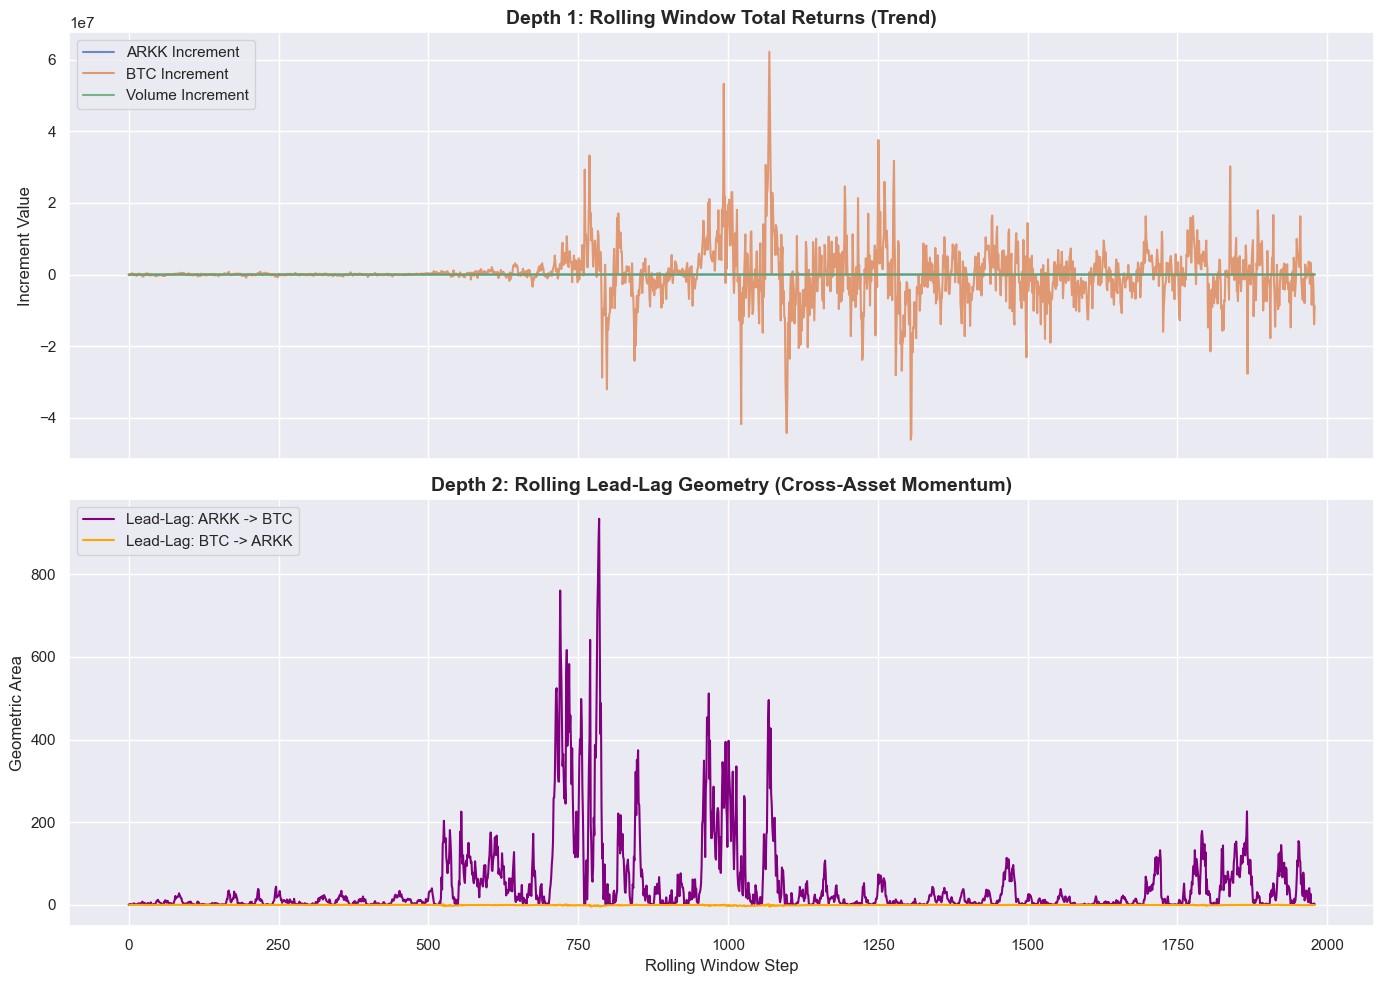

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

def analyze_signature_evolution(sig_matrix, feature_names=["Asset 1", "Asset 2", "Asset 3"]):
    """
    Plots the rolling evolution of Depth 1 and Depth 2 signature terms.
    Assumes a signature depth of 2 and 3 original features.
    """
    # esig outputs the "empty word" (1.0) at index 0. 
    # Indices 1, 2, 3 are the Depth 1 terms (window increments).
    # Indices 4 through 12 are the Depth 2 cross-terms.
    
    # Set up the plotting environment
    sns.set_theme(style="darkgrid")
    fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
    
    # --- PLOT 1: Depth 1 (Rolling Trends) ---
    axes[0].plot(sig_matrix[:, 1], label=f'{feature_names[0]} Increment', alpha=0.8)
    axes[0].plot(sig_matrix[:, 2], label=f'{feature_names[1]} Increment', alpha=0.8)
    axes[0].plot(sig_matrix[:, 3], label=f'{feature_names[2]} Increment', alpha=0.8)
    axes[0].set_title('Depth 1: Rolling Window Total Returns (Trend)', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('Increment Value')
    axes[0].legend(loc='upper left')
    
    # --- PLOT 2: Depth 2 (Lead-Lag Relationships) ---
    # Index 5 is (Feature 1, Feature 2) -> Area swept if Asset 1 leads Asset 2
    # Index 7 is (Feature 2, Feature 1) -> Area swept if Asset 2 leads Asset 1
    axes[1].plot(sig_matrix[:, 5], color='purple', label=f'Lead-Lag: {feature_names[0]} -> {feature_names[1]}')
    axes[1].plot(sig_matrix[:, 7], color='orange', label=f'Lead-Lag: {feature_names[1]} -> {feature_names[0]}')
    axes[1].set_title('Depth 2: Rolling Lead-Lag Geometry (Cross-Asset Momentum)', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('Geometric Area')
    axes[1].set_xlabel('Rolling Window Step')
    axes[1].legend(loc='upper left')
    
    plt.tight_layout()
    plt.show()

# --- RUN THE PLOT ---
# Assuming you used 3 features (e.g., ARKK Return, BTC Return, Volume)
analyze_signature_evolution(sig_X, feature_names=["ARKK", "BTC", "Volume"])

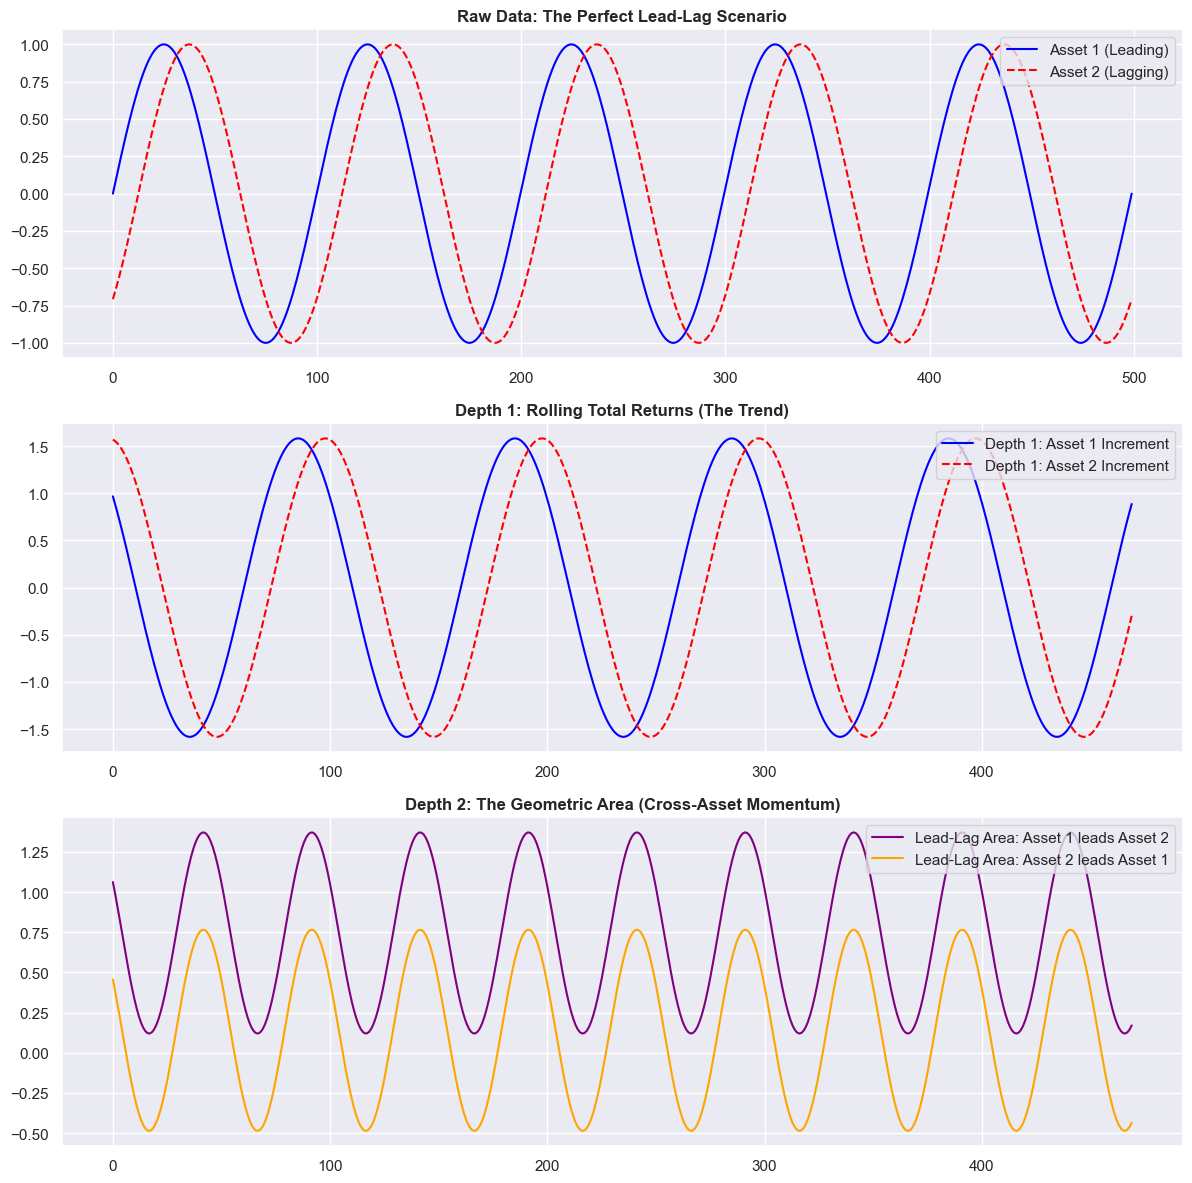

In [14]:
import numpy as np
import esig
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. GENERATE CONTROLLED DUMMY DATA
# ==========================================
# Create 500 time steps
t = np.linspace(0, 10 * np.pi, 500)

# Asset 1 is a standard Sine wave
asset1_lead = np.sin(t)

# Asset 2 is shifted by Pi/4. It exactly mimics Asset 1, but lags slightly behind.
asset2_lag = np.sin(t - np.pi/4) 

# Combine into our "DataFrame-like" array (500 days, 2 features)
dummy_data = np.column_stack((asset1_lead, asset2_lag))

# ==========================================
# 2. EXTRACT SIGNATURES
# ==========================================
window_size = 30
depth = 2
signatures = []

for i in range(len(dummy_data) - window_size):
    window = dummy_data[i : i + window_size]
    # Ensure memory is contiguous for the C++ engine
    window_clean = np.ascontiguousarray(window, dtype=np.float64)
    sig = esig.stream2sig(window_clean, depth)
    signatures.append(sig)

sig_matrix = np.array(signatures)

# ==========================================
# 3. VISUALIZE THE SIGNALS
# ==========================================
sns.set_theme(style="darkgrid")
fig, axes = plt.subplots(3, 1, figsize=(12, 12))

# PLOT 1: The Raw Data
axes[0].plot(dummy_data[:, 0], label="Asset 1 (Leading)", color='blue')
axes[0].plot(dummy_data[:, 1], label="Asset 2 (Lagging)", color='red', linestyle='--')
axes[0].set_title("Raw Data: The Perfect Lead-Lag Scenario", fontweight='bold')
axes[0].legend(loc='upper right')

# PLOT 2: Depth 1 (Trends)
# Index 0 is empty (1.0). Index 1 is Asset 1 Increment. Index 2 is Asset 2 Increment.
axes[1].plot(sig_matrix[:, 1], label="Depth 1: Asset 1 Increment", color='blue')
axes[1].plot(sig_matrix[:, 2], label="Depth 1: Asset 2 Increment", color='red', linestyle='--')
axes[1].set_title("Depth 1: Rolling Total Returns (The Trend)", fontweight='bold')
axes[1].legend(loc='upper right')

# PLOT 3: Depth 2 (Lead-Lag Geometry)
# For 2 features, Index 4 is (Asset 1 -> Asset 2) and Index 5 is (Asset 2 -> Asset 1)
axes[2].plot(sig_matrix[:, 4], color="purple", label="Lead-Lag Area: Asset 1 leads Asset 2")
axes[2].plot(sig_matrix[:, 5], color="orange", label="Lead-Lag Area: Asset 2 leads Asset 1")
axes[2].set_title("Depth 2: The Geometric Area (Cross-Asset Momentum)", fontweight='bold')
axes[2].legend(loc='upper right')

plt.tight_layout()
plt.show()

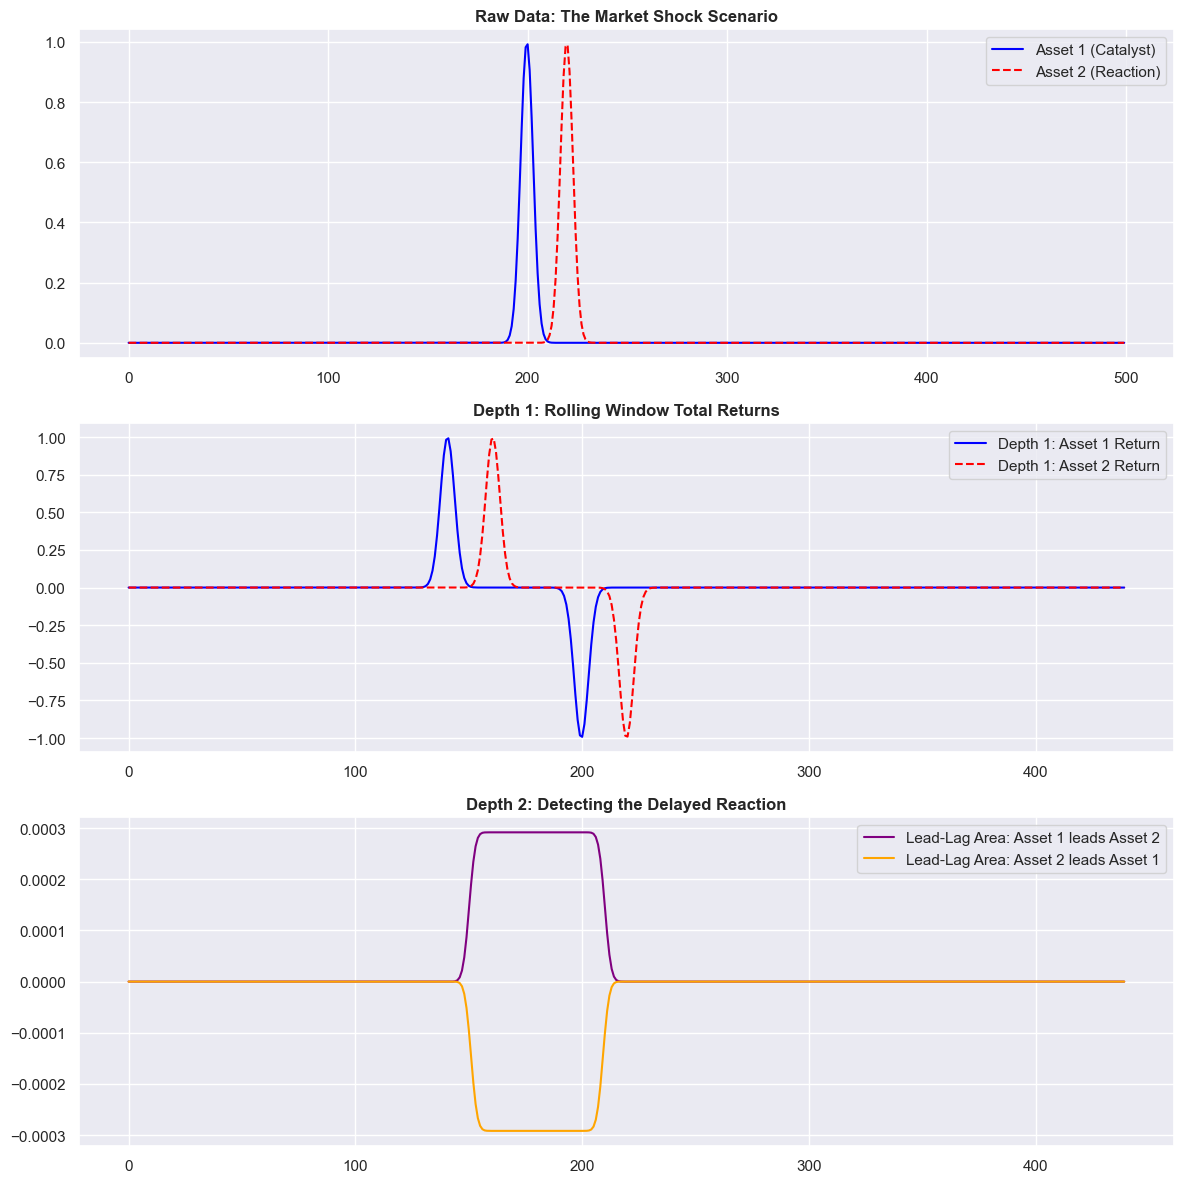

In [16]:
import numpy as np
import esig
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. GENERATE CONTROLLED DUMMY DATA (SHOCKS)
# ==========================================
# Create 500 time steps
t = np.linspace(0, 500, 500)

# Asset 1 (The Catalyst) is flat, but has a massive spike at day 200
asset1_shock = np.exp(-0.05 * (t - 200)**2)

# Asset 2 (The Reaction) is flat, but spikes at day 220 (20 days later)
asset2_reaction = np.exp(-0.05 * (t - 220)**2) 

# Combine into our "DataFrame-like" array (500 days, 2 features)
dummy_shock_data = np.column_stack((asset1_shock, asset2_reaction))

# ==========================================
# 2. EXTRACT SIGNATURES
# ==========================================
# We use a 60-day window so the window is large enough to "see" both spikes at the same time
window_size = 60
depth = 2
signatures = []

for i in range(len(dummy_shock_data) - window_size):
    window = dummy_shock_data[i : i + window_size]
    # Ensure memory is contiguous for the C++ engine
    window_clean = np.ascontiguousarray(window, dtype=np.float64)
    sig = esig.stream2sig(window_clean, depth)
    signatures.append(sig)

sig_matrix = np.array(signatures)

# ==========================================
# 3. VISUALIZE THE SIGNALS
# ==========================================
sns.set_theme(style="darkgrid")
fig, axes = plt.subplots(3, 1, figsize=(12, 12))

# PLOT 1: The Raw Data
axes[0].plot(dummy_shock_data[:, 0], label="Asset 1 (Catalyst)", color='blue')
axes[0].plot(dummy_shock_data[:, 1], label="Asset 2 (Reaction)", color='red', linestyle='--')
axes[0].set_title("Raw Data: The Market Shock Scenario", fontweight='bold')
axes[0].legend(loc='upper right')

# PLOT 2: Depth 1 (Trends)
axes[1].plot(sig_matrix[:, 1], label="Depth 1: Asset 1 Return", color='blue')
axes[1].plot(sig_matrix[:, 2], label="Depth 1: Asset 2 Return", color='red', linestyle='--')
axes[1].set_title("Depth 1: Rolling Window Total Returns", fontweight='bold')
axes[1].legend(loc='upper right')

# PLOT 3: Depth 2 (Lead-Lag Geometry)
axes[2].plot(sig_matrix[:, 4], color="purple", label="Lead-Lag Area: Asset 1 leads Asset 2")
axes[2].plot(sig_matrix[:, 5], color="orange", label="Lead-Lag Area: Asset 2 leads Asset 1")
axes[2].set_title("Depth 2: Detecting the Delayed Reaction", fontweight='bold')
axes[2].legend(loc='upper right')

plt.tight_layout()
plt.show()